In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BÖLÜM 0 — Veri kümesi, split ve dataloader
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os, random, json
from collections import defaultdict
 
C23_ROOT   = "/kaggle/input/datasets/asenaen/deepfake-frames-c23-face/deepfake_frames_face"
CELEB_ROOT = "/kaggle/input/datasets/asenaen/celebdf-test"
SPLIT_JSON = "/kaggle/working/dsf_splits_c23only.json"
KEEP_TYPES = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
SEED = 42
random.seed(SEED)
 
# Fake video listesi
fake_by_type = defaultdict(list)
for vid in os.listdir(os.path.join(C23_ROOT, "fake")):
    for t in KEEP_TYPES:
        if vid.startswith(t):
            fake_by_type[t].append(vid)
            break
 
real_vids = sorted(os.listdir(os.path.join(C23_ROOT, "real")))
 
# Stratified split — her türden 180/20/50
fake_train, fake_val, fake_test = [], [], []
for t in KEEP_TYPES:
    vids   = sorted(fake_by_type[t])
    chosen = random.sample(vids, 250)
    random.shuffle(chosen)
    fake_train.extend(chosen[:180])
    fake_val.extend(chosen[180:200])
    fake_test.extend(chosen[200:])
 
random.shuffle(real_vids)
real_train = real_vids[:720]
real_val   = real_vids[720:800]
real_test  = real_vids[800:]
 
splits = {
    "train": {"fake": fake_train, "real": real_train},
    "val":   {"fake": fake_val,   "real": real_val},
    "test":  {"fake": fake_test,  "real": real_test},
}
with open(SPLIT_JSON, "w") as f:
    json.dump(splits, f, indent=2)
 
print("Split:")
for sp in ["train", "val", "test"]:
    print(f"  {sp}: {len(splits[sp]['fake'])} fake, {len(splits[sp]['real'])} real")
print(f"✅ Kaydedildi: {SPLIT_JSON}")
 

Split:
  train: 720 fake, 720 real
  val: 80 fake, 80 real
  test: 200 fake, 200 real
✅ Kaydedildi: /kaggle/working/dsf_splits_c23only.json


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BÖLÜM 1 — Augmentation ve Dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
 
# ── augmentation pipeline ──────
def get_transforms(split="train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == "train":
        return transforms.Compose([
            transforms.Resize((256, 256)),          # önce büyük resize
            transforms.RandomCrop(224),             # sonra crop → konum varyasyonu
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2,
                saturation=0.1, hue=0.05),          # renk baskısı varyasyonu
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
            ], p=0.4),
            transforms.RandomApply([
                transforms.RandomAdjustSharpness(sharpness_factor=2)
            ], p=0.3),
            transforms.ToTensor(),
            transforms.RandomApply([
                transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.01)
            ], p=0.5),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # occlusion
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
# ── Mixup ve CutMix augmentation ──────────
# Sınır örneklerini öğrenmek için lineer interpolasyon
# ve rastgele yama ekleme. Label smoothing ile birlikte
# overfitting'i  azaltabilir.
def mixup_data(x, y, alpha=0.4):
    """Mixup: iki örneği doğrusal olarak karıştır."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    B = x.size(0)
    idx = torch.randperm(B, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam
 
def cutmix_data(x, y, alpha=1.0):
    """CutMix: bir görüntü parçasını başka bir görüntüden kes-yapıştır."""
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    idx = torch.randperm(B, device=x.device)
 
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
 
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
 
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam
 
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
 
 
class C23Dataset(Dataset):
    def __init__(self, split_json, split, transform=None):
        with open(split_json) as f:
            all_splits = json.load(f)
        data = all_splits[split]
        self.transform = transform
        self.samples   = []
        for vid in data["fake"]:
            folder = os.path.join(C23_ROOT, "fake", vid)
            if not os.path.isdir(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(folder, fname), 1))
        for vid in data["real"]:
            folder = os.path.join(C23_ROOT, "real", vid)
            if not os.path.isdir(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(folder, fname), 0))
        random.shuffle(self.samples)
        n_fake = sum(1 for _, l in self.samples if l == 1)
        n_real = sum(1 for _, l in self.samples if l == 0)
        print(f"  [C23 {split:5s}] {len(self.samples):>6} frame ({n_fake} fake / {n_real} real)")
 
    def __len__(self): return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label
 
class CelebDFDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        for label, folder in [(0, "real"), (1, "fake")]:
            path = os.path.join(root, folder)
            if not os.path.isdir(path): continue
            for fname in os.listdir(path):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(path, fname), label))
        random.shuffle(self.samples)
        n_fake = sum(1 for _, l in self.samples if l == 1)
        n_real = sum(1 for _, l in self.samples if l == 0)
        print(f"  [CelebDF test] {len(self.samples):>6} frame ({n_fake} fake / {n_real} real)")
 
    def __len__(self): return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label
 
def build_loaders(split_json, batch_size=16, num_workers=4):
    print("Dataset yükleniyor...\n")
    loaders = {}
    for split in ["train", "val", "test"]:
        tf = get_transforms(split)
        ds = C23Dataset(split_json, split, transform=tf)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True)
    celeb_ds = CelebDFDataset(CELEB_ROOT, transform=get_transforms("test"))
    loaders["celebdf"] = DataLoader(
        celeb_ds, batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True)
    return loaders
 
loaders = build_loaders(SPLIT_JSON, batch_size=16)
imgs, labels = next(iter(loaders["train"]))
print(f"\nBatch: {tuple(imgs.shape)}, labels: {labels.tolist()[:8]}")
 
 


Dataset yükleniyor...

  [C23 train]  14269 frame (7166 fake / 7103 real)
  [C23 val  ]   1582 frame (794 fake / 788 real)
  [C23 test ]   3966 frame (1991 fake / 1975 real)
  [CelebDF test]   2590 frame (1700 fake / 890 real)

Batch: (16, 3, 224, 224), labels: [1, 1, 0, 0, 1, 0, 0, 0]


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BÖLÜM 2 — Model mimarisi
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
!pip install timm pytorch_wavelets pywavelets -q
 
import torch.nn as nn
import torch.nn.functional as F
import timm, math
from pytorch_wavelets import DWTForward, DWTInverse
 
# ── DCT ─────────────────────────────────
class DCT(nn.Module):
    def __init__(self, N=8, in_channels=3):
        super().__init__()
        self.N = N
        self.in_channels = in_channels
        out_ch = N * N * in_channels
        weight = torch.from_numpy(self._mk_coff(N)).float().unsqueeze(1)
        self.dct_conv = nn.Conv2d(in_channels, out_ch, N, N,
                                  bias=False, groups=in_channels)
        self.dct_conv.weight.data = torch.cat([weight]*in_channels, dim=0)
        self.dct_conv.weight.requires_grad = False
        tm = torch.tensor([[0.299, 0.587, 0.114],
                            [-0.169, -0.331, 0.5],
                            [0.5, -0.419, -0.081]],
                           dtype=torch.float32).view(3,3,1,1)
        self.ycbcr = nn.Conv2d(3, 3, 1, bias=False)
        self.ycbcr.weight.data = tm
        self.ycbcr.weight.requires_grad = False
        itm = torch.tensor(
            np.linalg.pinv(np.array([[0.299, 0.587, 0.114],
                                     [-0.169, -0.331, 0.5],
                                     [0.5, -0.419, -0.081]])),
            dtype=torch.float32).view(3,3,1,1)
        self.iycbcr = nn.Conv2d(3, 3, 1, bias=False)
        self.iycbcr.weight.data = itm
        self.iycbcr.weight.requires_grad = False
 
    def forward(self, x):
        return self.dct_conv(self.ycbcr(x))
 
    def inverse(self, dct_feat):
        weight = torch.from_numpy(
            self._mk_coff(self.N)).float().unsqueeze(1).to(dct_feat.device)
        weight = torch.cat([weight]*self.in_channels, dim=0)
        ycbcr  = F.conv_transpose2d(
            dct_feat, weight, stride=self.N, groups=self.in_channels)
        return self.iycbcr(ycbcr)
 
    def _mk_coff(self, N=8):
        w = np.zeros((N*N, N, N))
        for k in range(N*N):
            u, v = k//N, k%N
            for i in range(N):
                for j in range(N):
                    cu = math.sqrt(1/N) if u==0 else math.sqrt(2/N)
                    cv = math.sqrt(1/N) if v==0 else math.sqrt(2/N)
                    w[k,i,j] = (cu*cv *
                                math.cos(math.pi*u*(i+0.5)/N) *
                                math.cos(math.pi*v*(j+0.5)/N))
        return self._zigzag(w, N)
 
    def _zigzag(self, src, N):
        out = src.copy()
        i, j = 0, 0
        for k in range(N*N - 1):
            if (i==0 or i==N-1) and j%2==0: j+=1
            elif (j==0 or j==N-1) and i%2==1: i+=1
            elif (i+j)%2==1: i+=1; j-=1
            else: i-=1; j+=1
            out[k+1] = src[i*N+j]
        return out
 
 
class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels//ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels//ratio, channels, 1, bias=False),
        )
        self.sig = nn.Sigmoid()
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight, gain=0.02)
 
    def forward(self, x):
        return self.sig(self.mlp(self.avg(x)) + self.mlp(self.max(x)))
 
 
# ── GIEM, LIEM, CoordAtt  ───────────────
class GIEM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels*2, channels*2, 1, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, Sdwt, Srgb):
        cat  = torch.cat([Sdwt, Srgb], dim=1)
        A1   = self.sig(self.conv(cat))
        A1w1, A1w2 = torch.chunk(A1, 2, dim=1)
        return (Sdwt * A1w1 + Sdwt) + (Srgb * A1w2 + Srgb)
 
class LIEM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels*2, channels*2, 1, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, Sdct, Srgb):
        cat  = torch.cat([Sdct, Srgb], dim=1)
        A3   = self.sig(self.conv(cat))
        A3w1, A3w2 = torch.chunk(A3, 2, dim=1)
        return (Srgb * A3w1 + Srgb) + (Sdct * A3w2 + Sdct)
 
class CoordAtt(nn.Module):
    def __init__(self, channels, reduction=32):
        super().__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        mid = max(8, channels//reduction)
        self.conv1  = nn.Conv2d(channels, mid, 1)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.Hardswish()
        self.conv_h = nn.Conv2d(mid, channels, 1)
        self.conv_w = nn.Conv2d(mid, channels, 1)
    def forward(self, x):
        n, c, h, w = x.shape
        xh = self.pool_h(x)
        xw = self.pool_w(x).permute(0,1,3,2)
        y  = self.act(self.bn1(self.conv1(torch.cat([xh, xw], dim=2))))
        xh, xw = torch.split(y, [h, w], dim=2)
        ah = self.conv_h(xh).sigmoid()
        aw = self.conv_w(xw.permute(0,1,3,2)).sigmoid()
        return x * ah * aw + x
 
class FreqAlignment(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels*2, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(True),
        )
    def forward(self, Fg, Fl):
        return self.block(torch.cat([Fg, Fl], dim=1))
 
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  CAFM — Çapraz-Dikkat Füzyon Modülü ───
# Cross-domain genelleştirme için frekans özellik
# uzayı ile RGB uzayı arasında çift yönlü bilgi akışı
# gerekiyor. CAFM bunu "query-key-value" tarzı dikkat ile
# sağlıyor — tam transformer dikkatinin aksine
# hesaplamalı olarak çok daha hafif.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class CAFM(nn.Module):
    """
    Cross-Attention Frequency Module.
    Frekans dalından (Sf) gelen bilginin RGB dalını (Sr) zenginleştirmesi
    için iki yönlü (Sf→Sr, Sr→Sf) çapraz dikkat.
 
    Neden tam attention değil?  
      224×224 girişte stage0 çıkışı 128ch, 56×56 → 3136 token.
      Bunlar arası tam dikkat O(3136²) = ~10M işlem/örnek → çok ağır.
      Burada global ortalama havuzlama ile sıkıştırılmış (B, C, 1, 1)
      sorgu vektörleri kullanılıyor; mekânsal yapı korunuyor.
    """
    def __init__(self, channels, heads=4):
        super().__init__()
        assert channels % heads == 0
        self.heads = heads
        self.scale = (channels // heads) ** -0.5
 
        # Sf → Sr yönü: frekans bilgisiyle RGB'yi yeniden ağırlıklandır
        self.q_rgb  = nn.Conv2d(channels, channels, 1, bias=False)
        self.k_freq = nn.Conv2d(channels, channels, 1, bias=False)
        self.v_freq = nn.Conv2d(channels, channels, 1, bias=False)
 
        # Sr → Sf yönü: RGB bilgisiyle frekansı yeniden ağırlıklandır
        self.q_freq = nn.Conv2d(channels, channels, 1, bias=False)
        self.k_rgb  = nn.Conv2d(channels, channels, 1, bias=False)
        self.v_rgb  = nn.Conv2d(channels, channels, 1, bias=False)
 
        self.out_rgb  = nn.Sequential(
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels))
        self.out_freq = nn.Sequential(
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels))
 
        self.gamma_r = nn.Parameter(torch.zeros(1))
        self.gamma_f = nn.Parameter(torch.zeros(1))
 
    def forward(self, Sr, Sf):
        """
        Sr: RGB stream özellikleri   (B, C, H, W)
        Sf: frekans stream özellikleri (B, C, H, W)
        """
        B, C, H, W = Sr.shape
        h = self.heads
        d = C // h
 
        def reshape(t):
            # (B, C, H, W) → (B, h, d, H*W)
            return t.view(B, h, d, H * W)
 
        # ── Sf → Sr dikkat ──────────────────────────
        Q_r = reshape(self.q_rgb(Sr))                       # (B,h,d,HW)
        K_f = reshape(self.k_freq(Sf))
        V_f = reshape(self.v_freq(Sf))
 
        # Global avg ile kanala sıkıştır → hafif Q
        Q_r_avg = Q_r.mean(dim=-1, keepdim=True)            # (B,h,d,1)
        attn_rf = (Q_r_avg * K_f * self.scale).softmax(-1)  # (B,h,d,HW)
        out_r   = (attn_rf * V_f).sum(-1, keepdim=True)     # (B,h,d,1)
        out_r   = out_r.expand_as(Q_r).reshape(B, C, H, W)
        Sr_out  = Sr + self.gamma_r * self.out_rgb(out_r)
 
        # ── Sr → Sf dikkat ──────────────────────────
        Q_f = reshape(self.q_freq(Sf))
        K_r = reshape(self.k_rgb(Sr))
        V_r = reshape(self.v_rgb(Sr))
 
        Q_f_avg = Q_f.mean(dim=-1, keepdim=True)
        attn_fr = (Q_f_avg * K_r * self.scale).softmax(-1)
        out_f   = (attn_fr * V_r).sum(-1, keepdim=True)
        out_f   = out_f.expand_as(Q_f).reshape(B, C, H, W)
        Sf_out  = Sf + self.gamma_f * self.out_freq(out_f)
 
        return Sr_out, Sf_out
 
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  AuxHead — frekans dalı için ek gözetim
# Neden: Eğitim sırasında frekans dalının gradyan almak için
# yalnızca head'deki kayba bağlı olması zayıf bir sinyal.
# Dalı bağımsız "fake mi?" sorusuna da cevap vermek üzere
# eğitmek, backbone'un frekans özelliklerini daha genel
# temsillere çevirmesini zorluyor → cross-domain fark azalır.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class AuxHead(nn.Module):
    def __init__(self, in_ch, num_classes=2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(in_ch, num_classes)
    def forward(self, x):
        return self.fc(self.pool(x).flatten(1))
 
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Ana Model: DSF_Ext ────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class DSF_Ext(nn.Module):
    """
    DSF_Ext  = DSF + CAFM + AuxHead + stage1 skip bağlantısı
 
    Forward çıktısı:
      Eğitim modunda: (logits, aux_logits)  ← ikili tuple
      Değerlendirme modunda: logits          ← tek tensor
    """
    def __init__(self, num_classes=2):
        super().__init__()
 
        backbone    = timm.create_model("convnext_base", pretrained=True)
        self.stem   = backbone.stem
        self.stage0 = backbone.stages[0]   # 128ch, 56×56
        self.stage1 = backbone.stages[1]   # 256ch, 28×28
        self.stage2 = backbone.stages[2]
        self.stage3 = backbone.stages[3]
        self.norm   = backbone.norm_pre
        self.head   = backbone.head
        in_f = self.head.fc.in_features
        self.head.fc = nn.Linear(in_f, num_classes)
        self.head.drop.p = 0.4              # dropout
 
        self.dct = DCT()
        self.xfm = DWTForward(J=1, mode="zero", wave="haar")
        self.ifm = DWTInverse(mode="zero", wave="haar")
        self.ca  = ChannelAttention(192)
 
        ch = 128
        self.giem  = GIEM(ch)
        self.liem  = LIEM(ch)
        self.ssem  = CoordAtt(ch)
        self.align = FreqAlignment(ch)
 
        # ── Yeni bileşenler ──────────────────────────
        # 1. CAFM: hem DWT hem DCT dalından ayrı çapraz-dikkat
        self.cafm_dwt = CAFM(ch, heads=4)
        self.cafm_dct = CAFM(ch, heads=4)
 
        # 2. Birleşik frekans özelliği için proje katmanı
        #    (dwt_enriched + dct_enriched → ch)
        self.freq_proj = nn.Sequential(
            nn.Conv2d(ch * 2, ch, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.GELU(),
        )
 
        # 3. Stage1 çıkışına skip bağlantı (256ch)
        #    Fen (128ch) → 256ch ile eşleştir
        self.skip_proj = nn.Sequential(
            nn.Conv2d(ch, ch * 2, 1, bias=False),   # 128 → 256
            nn.BatchNorm2d(ch * 2),
            nn.AvgPool2d(2, 2),                      # 56 → 28 (stage1 çıkış boyutu)
        )
 
        # 4. AuxHead: FCEM çıkışından bağımsız sınıflandırma
        self.aux_head = AuxHead(ch, num_classes)
 
    def _dwt_branch(self, x):
        Yl, Yh = self.xfm(x)
        return self.ifm((torch.zeros_like(Yl), Yh))
 
    def _dct_branch(self, x):
        dct = self.dct(x)
        ca  = self.ca(dct)
        return self.dct.inverse(dct * ca)
 
    def forward(self, x):
        dwt_img = self._dwt_branch(x)
        dct_img = self._dct_branch(x)
 
        # Stem + stage0 tek geçişte 
        combined = torch.cat([x, dwt_img, dct_img], dim=0)
        combined = self.stem(combined)
        combined = self.stage0(combined)
 
        B = x.size(0)
        Srgb = combined[:B]
        Sdwt = combined[B:2*B]
        Sdct = combined[2*B:]
 
        # FCEM bileşenleri
        Fs  = self.ssem(Srgb)
        Fg  = self.giem(Sdwt, Srgb)
        Fl  = self.liem(Sdct, Srgb)
        Fen = self.align(Fg, Fl) + Fs     # makale Eq.14
 
        # ──  CAFM ile çift yönlü frekans-RGB etkileşimi
        # DWT dalı: Srgb ↔ Fg (GIEM tarafından zaten RGB bilgisiyle zenginleştirildi)
        Srgb_dwt, Fg_cross = self.cafm_dwt(Srgb, Fg)
        # DCT dalı: zenginleştirilmiş RGB ↔ Fl
        Srgb_dct, Fl_cross = self.cafm_dct(Srgb_dwt, Fl)
 
        # Çapraz dikkat sonrası frekans özelliklerini birleştirme
        Ffreq = self.freq_proj(torch.cat([Fg_cross, Fl_cross], dim=1))
 
        # Son füzyon
        Fen_ext = Fen + Ffreq + Srgb_dct
 
        # AuxHead (eğitimde kullanılır)
        aux_out = self.aux_head(Fen_ext)
 
        # Kalan stage'ler
        x_out = self.stage1(Fen_ext)
 
        # ──  Stage1 skip bağlantısı
        skip = self.skip_proj(Fen_ext)
        x_out = x_out + skip             # ← residual; boyutlar eşit
 
        x_out = self.stage2(x_out)
        x_out = self.stage3(x_out)
        x_out = self.norm(x_out)
        x_out = self.head(x_out)
 
        if self.training:
            return x_out, aux_out
        return x_out
 
 
# ── Test ─────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = DSF_Ext(num_classes=2).to(device)
 
total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Toplam parametre : {total:.2f}M")
print(f"Eğitilebilir     : {trainable:.2f}M")
 
dummy = torch.rand(2, 3, 224, 224).to(device)
model.train()
out, aux = model(dummy)
print(f"Çıktı boyutu (train) : {tuple(out.shape)}, aux: {tuple(aux.shape)}")
model.eval()
out = model(dummy)
print(f"Çıktı boyutu (eval)  : {tuple(out.shape)}")
print("✅ DSF_Ext hazır")
 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.6 MB/s eta 0:00:0000:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cud

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Toplam parametre : 88.50M
Eğitilebilir     : 88.49M
Çıktı boyutu (train) : (2, 2), aux: (2, 2)
Çıktı boyutu (eval)  : (2, 2)
✅ DSF_Ext hazır


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BÖLÜM 3 — Eğitim
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import time, os
 
CKPT_DIR = "/kaggle/working/checkpoints_ext"
os.makedirs(CKPT_DIR, exist_ok=True)
 
NUM_EPOCHS = 25
AUX_WEIGHT = 0.3      # ana kayıp × 1.0, aux kayıp × 0.3
MIXUP_PROB = 0.5      # her batch'te %50 olasılıkla Mixup/CutMix uygulama
LABEL_SMOOTH = 0.05   # küçük label smoothing
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Kademeli Unfreeze + Warmup stratejisi
# Neden: Frekans dallarını başlangıçta dondurarak backbone'un
# önce RGB özelliklerini oturtmasını sağlamak için. Warmup
# ile büyük LR'ın erken dönemdeki zarar vermesini engelliyoruz.
# 5. epoch'tan sonra tüm parametreler serbest → ince ayar.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FREEZE_EPOCHS   = 3    # ilk 3 epoch: frekans dalları dondurulmuş
WARMUP_EPOCHS   = 2    # ilk 2 epoch: LR sıfırdan BASE_LR'a çıkar
BASE_LR         = 5e-5
FREQ_LR_FACTOR  = 0.5  # frekans bileşenleri için daha düşük LR
 
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
criterion_hard   = nn.CrossEntropyLoss()   # val/test için
 
def freeze_freq_branches(model):
    """DCT, DWT ve CA ağırlıklarını dondur."""
    for name, param in model.named_parameters():
        if any(k in name for k in ["dct", "xfm", "ifm", "ca."]):
            param.requires_grad = False
 
def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
 
def build_optimizer(model, epoch):
    """
    Epoch'a göre farklı parametre grupları ve LR'lar.
    Frekans bileşenlerine daha küçük LR uygulanır.
    """
    freq_names = {"dct", "xfm", "ifm", "ca.", "cafm", "freq_proj"}
    freq_params, base_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        if any(k in name for k in freq_names):
            freq_params.append(p)
        else:
            base_params.append(p)
    return torch.optim.AdamW([
        {"params": base_params, "lr": BASE_LR},
        {"params": freq_params, "lr": BASE_LR * FREQ_LR_FACTOR},
    ], betas=(0.9, 0.999), weight_decay=1e-4)
 
def get_lr_scale(epoch, warmup=WARMUP_EPOCHS):
    """Warmup: 0 → 1 lineer artış."""
    if epoch <= warmup:
        return epoch / warmup
    return 1.0
 
 
def train_one_epoch(model, loader, optimizer, scaler, device, epoch):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
 
    # LR warmup
    scale = get_lr_scale(epoch)
    for pg in optimizer.param_groups:
        pg["lr"] = pg["initial_lr"] * scale
 
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
 
        # Mixup / CutMix kararı
        use_mix = random.random() < MIXUP_PROB
        if use_mix:
            if random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=0.4)
            else:
                imgs, y_a, y_b, lam = cutmix_data(imgs, labels, alpha=1.0)
 
        with torch.amp.autocast('cuda'):
            logits, aux_logits = model(imgs)
 
            if use_mix:
                main_loss = mixup_criterion(criterion_smooth, logits, y_a, y_b, lam)
                aux_loss  = mixup_criterion(criterion_smooth, aux_logits, y_a, y_b, lam)
            else:
                main_loss = criterion_smooth(logits, labels)
                aux_loss  = criterion_smooth(aux_logits, labels)
 
            loss = main_loss + AUX_WEIGHT * aux_loss
 
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
 
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
 
    return total_loss / n, correct / n
 
 
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels  = [], []
 
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)          # eval modda tek tensor
            loss = criterion_hard(out, labels)
 
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
 
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, correct / n, auc
 
 
# ── Eğitim döngüsü ──────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = DSF_Ext(num_classes=2).to(device)
scaler    = torch.amp.GradScaler('cuda')
best_auc  = 0.0
history   = []
 
# İlk freeze
freeze_freq_branches(model)
print(f"İlk {FREEZE_EPOCHS} epoch frekans dalları donduruldu.\n")
 
# initial_lr'ları sakla (warmup için)
optimizer = build_optimizer(model, epoch=1)
for pg in optimizer.param_groups:
    pg["initial_lr"] = pg["lr"]
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
 
print(f"{'Ep':>3} {'TrLoss':>8} {'TrAcc':>7} {'VaLoss':>8} "
      f"{'VaAcc':>7} {'VaAUC':>7}  Durum")
print("-" * 70)
 
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
 
    # Kademeli unfreeze
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_all(model)
        #  (artık tüm parametreler aktif)
        optimizer = build_optimizer(model, epoch)
        for pg in optimizer.param_groups:
            pg["initial_lr"] = pg["lr"]
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - epoch + 1, eta_min=1e-6)
        print(f"  [Epoch {epoch}] Tüm parametreler serbest bırakıldı.")
 
    tr_loss, tr_acc = train_one_epoch(
        model, loaders["train"], optimizer, scaler, device, epoch)
    va_loss, va_acc, va_auc = evaluate(model, loaders["val"], device)
 
    if epoch > WARMUP_EPOCHS:
        scheduler.step()
 
    mark = ""
    if va_auc > best_auc:
        best_auc = va_auc
        ckpt_data = {
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "val_auc"    : va_auc,
            "optimizer"  : optimizer.state_dict(),
        }
        torch.save(ckpt_data, os.path.join(CKPT_DIR, "best_model.pth"))
        torch.save(ckpt_data, os.path.join(CKPT_DIR, f"best_epoch_{epoch}.pth"))
        mark = " ← en iyi"
 
    elapsed = time.time() - t0
    print(f"{epoch:3d} {tr_loss:8.4f} {tr_acc:7.4f} {va_loss:8.4f} "
          f"{va_acc:7.4f} {va_auc:7.4f} [{elapsed:.0f}s]{mark}")
 
    history.append(dict(
        epoch=epoch,
        tr_loss=tr_loss, tr_acc=tr_acc,
        va_loss=va_loss, va_acc=va_acc, va_auc=va_auc))
 
print(f"\nEğitim tamamlandı. En iyi Val AUC: {best_auc:.4f}")

İlk 3 epoch frekans dalları donduruldu.

 Ep   TrLoss   TrAcc   VaLoss   VaAcc   VaAUC  Durum
----------------------------------------------------------------------
  1   0.7783  0.6928   0.4501  0.7851  0.8776 [390s] ← en iyi
  2   0.6421  0.7948   0.6688  0.7509  0.9027 [362s] ← en iyi
  3   0.5577  0.8465   0.4387  0.8325  0.9235 [361s] ← en iyi
  [Epoch 4] Tüm parametreler serbest bırakıldı.
  4   0.5302  0.8566   0.3604  0.8515  0.9265 [427s] ← en iyi
  5   0.5108  0.8680   0.5134  0.8021  0.8897 [422s]
  6   0.4814  0.8799   0.5201  0.8388  0.9207 [422s]
  7   0.4767  0.8841   0.5767  0.8072  0.9223 [422s]
  8   0.4698  0.8902   0.5240  0.8161  0.9222 [422s]
  9   0.4512  0.8942   0.4685  0.8515  0.9252 [421s]
 10   0.4522  0.8889   0.5063  0.8325  0.9292 [425s] ← en iyi
 11   0.4383  0.9057   0.6854  0.7927  0.9084 [422s]
 12   0.4302  0.8978   0.4685  0.8394  0.9210 [422s]
 13   0.4168  0.8917   0.5145  0.8382  0.9257 [422s]
 14   0.4201  0.8990   0.6481  0.8009  0.9086 [422s]


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BÖLÜM 4 — Test (C23 + Celeb-DF)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from sklearn.metrics import accuracy_score
 
ckpt = torch.load(
    os.path.join(CKPT_DIR, "best_model.pth"),
    map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Checkpoint yüklendi — Epoch {ckpt['epoch']}, Val AUC: {ckpt['val_auc']:.4f}")
 
for split_name, loader_key in [("C23 Test", "test"), ("Celeb-DF", "celebdf")]:
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loaders[loader_key]:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
 
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, [1 if p > 0.5 else 0 for p in all_probs])
    print(f"{split_name:10s} →  AUC: {auc:.4f}  ACC: {acc:.4f}")
 
print(f"\n{'─'*40}")
print(f"DSF_Ext      Celeb-DF AUC : {auc:.4f} ")
 

NameError: name 'CKPT_DIR' is not defined

DFD: 958 fake video | 9503 fake frame | 9866 real frame
Checkpoint: Epoch 25, Val AUC: 0.9449

AUC: 0.8428 | ACC: 0.7137 | Sensitivity: 0.4511 | Specificity: 0.9666


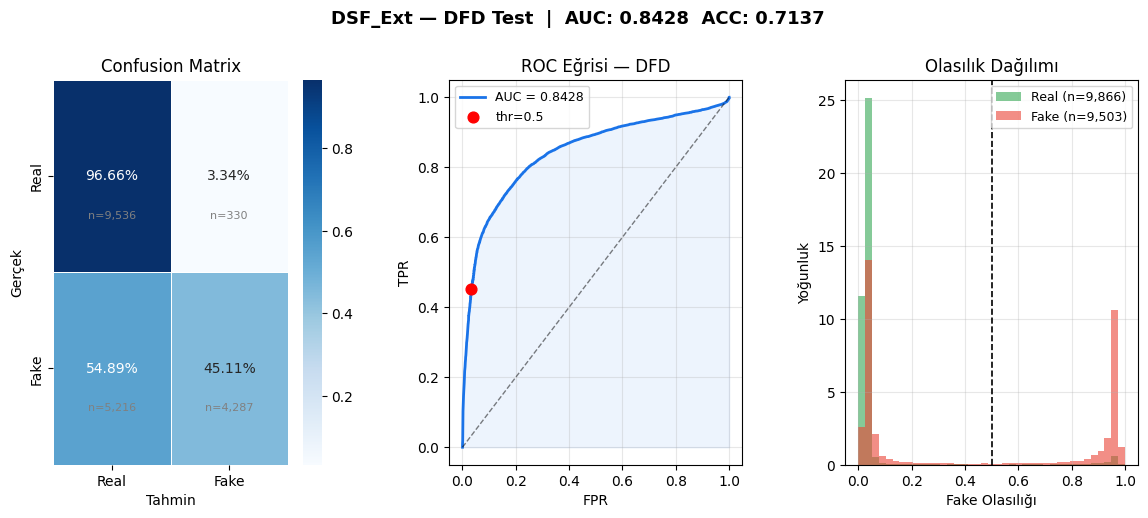


Video-level → AUC: 0.9093 | ACC: 0.7043 | Toplam video: 1958


In [8]:
"""
DFD Test 
"""

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict
import os, random

C23_ROOT   = "/kaggle/input/datasets/asenaen/deepfake-frames-c23-face/deepfake_frames_face"
CKPT_PATH  = "/kaggle/working/checkpoints_ext/best_model.pth"
DFD_PREFIX = "DeepFakeDetection"

# ── Dataset ──────────────────────────────────────────────
class DFDDataset(Dataset):
    def __init__(self, root, prefix=DFD_PREFIX, transform=None, seed=42):
        random.seed(seed)
        self.transform = transform
        self.samples   = []

        fake_dir = os.path.join(root, "fake")
        dfd_vids = [v for v in sorted(os.listdir(fake_dir)) if v.startswith(prefix)]
        if not dfd_vids:
            raise FileNotFoundError(f"'{prefix}' ile başlayan klasör bulunamadı.\nMevcut: {os.listdir(fake_dir)[:10]}")

        for vid in dfd_vids:
            folder = os.path.join(fake_dir, vid)
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(folder, fname), 1, vid))

        real_dir = os.path.join(root, "real")
        for vid in sorted(os.listdir(real_dir)):
            folder = os.path.join(real_dir, vid)
            if not os.path.isdir(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(folder, fname), 0, vid))

        random.shuffle(self.samples)
        n_fake = sum(1 for _,l,_ in self.samples if l==1)
        n_real = sum(1 for _,l,_ in self.samples if l==0)
        print(f"DFD: {len(dfd_vids)} fake video | {n_fake} fake frame | {n_real} real frame")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label, vid = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, vid

tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

dfd_ds     = DFDDataset(C23_ROOT, transform=tf)
dfd_loader = DataLoader(dfd_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# ── Checkpoint yükle (model zaten tanımlı) ───────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Checkpoint: Epoch {ckpt['epoch']}, Val AUC: {ckpt['val_auc']:.4f}")

# ── Inference ────────────────────────────────────────────
all_probs, all_labels, all_vids = [], [], []
with torch.no_grad():
    for imgs, labels, vids in dfd_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = F.softmax(out, dim=1)[:,1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
        all_vids.extend(vids)

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs > 0.5).astype(int)

# ── Metrikler ────────────────────────────────────────────
dfd_auc = roc_auc_score(all_labels, all_probs)
dfd_acc = accuracy_score(all_labels, all_preds)
cm      = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp+fn)>0 else 0
specificity = tn / (tn + fp) if (tn+fp)>0 else 0

print(f"\nAUC: {dfd_auc:.4f} | ACC: {dfd_acc:.4f} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")

# ── Görselleştirme ───────────────────────────────────────
fpr_arr, tpr_arr, thrs = roc_curve(all_labels, all_probs)

fig = plt.figure(figsize=(14,5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)

# Confusion matrix
ax1 = fig.add_subplot(gs[0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"],
            ax=ax1, linewidths=0.5, linecolor="white")
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.72, f"n={cm[i,j]:,}", ha="center", fontsize=8, color="gray")
ax1.set_title("Confusion Matrix"); ax1.set_xlabel("Tahmin"); ax1.set_ylabel("Gerçek")

# ROC
ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr_arr, tpr_arr, color="#1a73e8", lw=2, label=f"AUC = {dfd_auc:.4f}")
ax2.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax2.fill_between(fpr_arr, tpr_arr, alpha=0.08, color="#1a73e8")
op_i = np.argmin(np.abs(thrs - 0.5))
ax2.scatter(fpr_arr[op_i], tpr_arr[op_i], color="red", s=60, zorder=5, label="thr=0.5")
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR"); ax2.set_title("ROC Eğrisi — DFD")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Olasılık dağılımı
ax3 = fig.add_subplot(gs[2])
bins = np.linspace(0,1,40)
ax3.hist(all_probs[all_labels==0], bins=bins, alpha=0.6, color="#34a853", label=f"Real (n={int((all_labels==0).sum()):,})", density=True)
ax3.hist(all_probs[all_labels==1], bins=bins, alpha=0.6, color="#ea4335", label=f"Fake (n={int((all_labels==1).sum()):,})", density=True)
ax3.axvline(0.5, color="black", linestyle="--", lw=1.2)
ax3.set_xlabel("Fake Olasılığı"); ax3.set_ylabel("Yoğunluk"); ax3.set_title("Olasılık Dağılımı")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

fig.suptitle(f"DSF_Ext — DFD Test  |  AUC: {dfd_auc:.4f}  ACC: {dfd_acc:.4f}", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("/kaggle/working/dfd_test_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Video-level ──────────────────────────────────────────
vid_probs_d, vid_labels_d = defaultdict(list), {}
for prob, label, vid in zip(all_probs, all_labels, all_vids):
    vid_probs_d[vid].append(prob)
    vid_labels_d[vid] = label

vid_res = [(vid, np.mean(ps), vid_labels_d[vid]) for vid, ps in vid_probs_d.items()]
vid_res.sort(key=lambda x: x[1], reverse=True)

vl = np.array([r[2] for r in vid_res])
vp = np.array([r[1] for r in vid_res])
if len(np.unique(vl)) > 1:
    print(f"\nVideo-level → AUC: {roc_auc_score(vl,vp):.4f} | ACC: {accuracy_score(vl,(vp>0.5).astype(int)):.4f} | Toplam video: {len(vid_res)}")

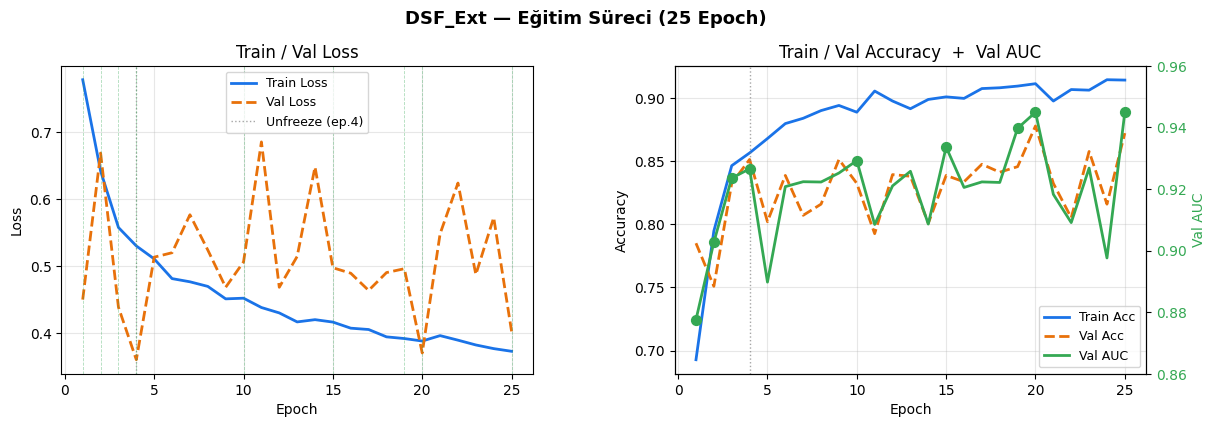

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# history zaten hafızada — direkt kullan
epochs  = [h["epoch"]   for h in history]
tr_loss = [h["tr_loss"] for h in history]
va_loss = [h["va_loss"] for h in history]
tr_acc  = [h["tr_acc"]  for h in history]
va_acc  = [h["va_acc"]  for h in history]
va_auc  = [h["va_auc"]  for h in history]
best_epochs = [h["epoch"] for h in history if h["va_auc"] == max(h["va_auc"] for h in history)]

# En iyi checkpoint epoch'larını bul
best_val = 0
best_epochs = []
for h in history:
    if h["va_auc"] > best_val:
        best_val = h["va_auc"]
        best_epochs.append(h["epoch"])

fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 2, wspace=0.3)

# ── Loss ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs, tr_loss, color="#1a73e8", lw=2, label="Train Loss")
ax1.plot(epochs, va_loss, color="#e8710a", lw=2, ls="--", label="Val Loss")
ax1.axvline(4, color="gray", lw=1, ls=":", alpha=0.7, label="Unfreeze (ep.4)")
for e in best_epochs:
    ax1.axvline(e, color="#34a853", lw=0.6, ls="--", alpha=0.4)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Train / Val Loss")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# ── Acc + AUC ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs, tr_acc, color="#1a73e8", lw=2, label="Train Acc")
ax2.plot(epochs, va_acc, color="#e8710a", lw=2, ls="--", label="Val Acc")
ax2.axvline(4, color="gray", lw=1, ls=":", alpha=0.7)

ax2r = ax2.twinx()
ax2r.plot(epochs, va_auc, color="#34a853", lw=2, label="Val AUC")
best_auc_pts = [va_auc[i] if epochs[i] in best_epochs else None for i in range(len(epochs))]
ax2r.scatter(
    [e for e,v in zip(epochs,best_auc_pts) if v is not None],
    [v for v in best_auc_pts if v is not None],
    color="#34a853", s=50, zorder=5)
ax2r.set_ylabel("Val AUC", color="#34a853")
ax2r.tick_params(axis='y', labelcolor="#34a853")
ax2r.set_ylim(0.86, 0.96)

ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Train / Val Accuracy  +  Val AUC")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("DSF_Ext — Eğitim Süreci (25 Epoch)", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**EĞİTİME DEVAM ETME**

In [ ]:
# ── Checkpoint'ten yükle ──────────────────────────────────
ckpt = torch.load("/kaggle/working/checkpoints_ext/best_model.pth",
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Epoch {ckpt['epoch']}'den devam ediliyor, Val AUC: {ckpt['val_auc']:.4f}")

# ── Devam parametreleri ───────────────────────────────────
START_EPOCH = ckpt["epoch"] + 1   # 26
END_EPOCH   = ckpt["epoch"] + 10  # 35
BASE_LR     = 2e-5                # daha düşük LR — model olgunlaştı

# ── Optimizer ve scheduler ────────────────────────────────
optimizer = build_optimizer(model, epoch=START_EPOCH)
for pg in optimizer.param_groups:
    pg["initial_lr"] = pg["lr"]

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10, eta_min=1e-6)

scaler   = torch.amp.GradScaler('cuda')
best_auc = ckpt["val_auc"]   # 0.9449'dan başla

print(f"\n{'Ep':>3} {'TrLoss':>8} {'TrAcc':>7} {'VaLoss':>8} "
      f"{'VaAcc':>7} {'VaAUC':>7}  Durum")
print("-" * 70)

for epoch in range(START_EPOCH, END_EPOCH + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, loaders["train"], optimizer, scaler, device, epoch)
    va_loss, va_acc, va_auc = evaluate(model, loaders["val"], device)
    scheduler.step()

    mark = ""
    if va_auc > best_auc:
        best_auc = va_auc
        ckpt_data = {
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "val_auc"    : va_auc,
            "optimizer"  : optimizer.state_dict(),
        }
        torch.save(ckpt_data, "/kaggle/working/checkpoints_ext/best_model.pth")
        torch.save(ckpt_data, f"/kaggle/working/checkpoints_ext/best_epoch_{epoch}.pth")
        mark = " ← en iyi"

    elapsed = time.time() - t0
    print(f"{epoch:3d} {tr_loss:8.4f} {tr_acc:7.4f} {va_loss:8.4f} "
          f"{va_acc:7.4f} {va_auc:7.4f} [{elapsed:.0f}s]{mark}")

    history.append(dict(
        epoch=epoch,
        tr_loss=tr_loss, tr_acc=tr_acc,
        va_loss=va_loss, va_acc=va_acc, va_auc=va_auc))

print(f"\nTamamlandı. En iyi Val AUC: {best_auc:.4f}")

Epoch 25'den devam ediliyor, Val AUC: 0.9449

 Ep   TrLoss   TrAcc   VaLoss   VaAcc   VaAUC  Durum
----------------------------------------------------------------------
 26   0.3578  0.9144   0.5318  0.8401  0.9346 [418s]
 27   0.3514  0.9098   0.5387  0.8331  0.9267 [422s]
 28   0.3481  0.9144   0.4975  0.8483  0.9193 [421s]
 29   0.3533  0.9113   0.5041  0.8439  0.9220 [421s]
 30   0.3580  0.9053   0.4716  0.8622  0.9365 [422s]
 31   0.3452  0.9177   0.5173  0.8407  0.9177 [422s]
 32   0.3588  0.9074   0.4371  0.8654  0.9148 [422s]


KeyboardInterrupt: 